# Teacher Imitator Rollout with Termination Checking

This notebook rolls out a trained teacher imitator (PPO) on imitation sequences and applies the same termination criteria used in `PriorRolloutEvaluator`.

Purpose: Validate the termination criteria by observing when/why the teacher gets terminated.

Termination criteria (from `prior_rollout.check_termination`):
1. NaN detection in qpos/qvel
2. Torso z-height outside healthy range (default: 0.0325 to 0.5)

In [1]:
# Add packages to path if not installed
import sys
sys.path.insert(0, '/home/mila/a/aidan.sirbu/track-mjx')
sys.path.insert(0, '/home/mila/a/aidan.sirbu/vnl-playground')

In [2]:
%load_ext autoreload
%autoreload 2

import os
import sys
from typing import Callable, Dict, Tuple, Any, Optional

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

# Set rendering backend
if sys.platform == "darwin":
    os.environ["MUJOCO_GL"] = "glfw"
    print("Using macOS with GLFW rendering")
else:
    os.environ["MUJOCO_GL"] = "egl"
    print("Using Linux with EGL rendering")

import jax
import jax.numpy as jnp
from jax import random
import numpy as np
from ml_collections import config_dict
from omegaconf import OmegaConf
import mediapy as media
import matplotlib.pyplot as plt

# vnl-playground imports for environment
from vnl_playground.tasks.rodent import imitation
from vnl_playground.tasks.rodent.wrappers import FlattenObsWrapper

# track-mjx imports
from track_mjx.agent import checkpointing
from track_mjx.agent.mlp_ppo import prior_rollout

print(f"JAX version: {jax.__version__}")
print(f"Available devices: {jax.devices()}")

Using Linux with EGL rendering
JAX version: 0.7.2
Available devices: [CudaDevice(id=0)]


## Configuration

In [ ]:
# Path to your trained teacher (PPO) checkpoint
CHECKPOINT_PATH = "/home/mila/a/aidan.sirbu/scratch/track-mjx/model_checkpoints/251210_204401_323736"

# Checkpoint settings (unified step prefix for both PPO and distillation pipelines)
STEP_PREFIX = "Network"
CHECKPOINT_STEP = None  # None = latest

# Rollout settings
NUM_STEPS = 500          # Number of steps per rollout
NUM_ROLLOUTS = 5         # Number of rollouts to run
DETERMINISTIC = True     # Use deterministic policy for reproducibility

# Termination settings (same as PriorRolloutEvaluator defaults)
HEALTHY_Z_RANGE = (0.0325, 0.5)  # Healthy torso height range

## 1. Load Teacher Checkpoint

In [5]:
# Load checkpoint
ckpt = checkpointing.load_checkpoint_for_eval(
    CHECKPOINT_PATH, 
    step_prefix=STEP_PREFIX, 
    step=CHECKPOINT_STEP
)
cfg = ckpt["cfg"]
policy_params = ckpt["policy"]

# Display config info
network_config = cfg.get("network_config", cfg)
print(f"Checkpoint loaded!")
print(f"Observation size: {network_config['observation_size']}")
print(f"Reference obs size: {network_config['reference_obs_size']}")
print(f"Proprioceptive obs size: {network_config['proprioceptive_obs_size']}")
print(f"Action size: {network_config['action_size']}")
print(f"Intention latent size: {network_config['intention_size']}")

Loading checkpoint from /home/mila/a/aidan.sirbu/scratch/track-mjx/model_checkpoints/251210_204401_323736 at step 109
Checkpoint loaded!
Observation size: 904
Reference obs size: 640
Proprioceptive obs size: 264
Action size: 38
Intention latent size: 60


## 2. Create Environment

In [6]:
def create_environment(cfg):
    """Create the imitation environment from checkpoint config."""
    env_cfg = cfg.get("env_config", cfg)
    if hasattr(env_cfg, 'to_container'):
        env_cfg_dict = OmegaConf.to_container(env_cfg, resolve=True)
    else:
        env_cfg_dict = dict(env_cfg)
    env_cfg_ml = config_dict.ConfigDict(env_cfg_dict)
    return FlattenObsWrapper(imitation.Imitation(config=env_cfg_ml))

env = create_environment(cfg)
print(f"Environment created!")
print(f"Action size: {env.action_size}")

Environment created!
Action size: 38


## 2.5 Visualize Neutral Pose at Different Z-Heights

Use this cell to find the z-height threshold where the rodent clips through the ground (fallen state).

Z-height: -0.01
Healthy range: (0.0325, 0.5)
Status: WOULD TERMINATE


Neutral Pose at z = -0.01

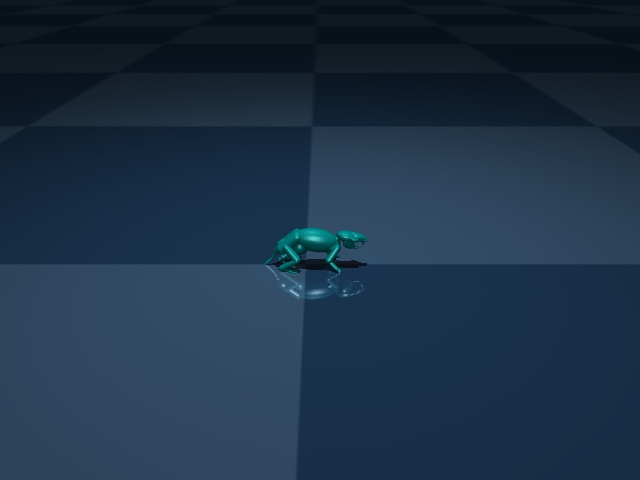

In [22]:
import mujoco

# ============================================================
# CHANGE THIS VALUE to test different z-heights
# ============================================================
TEST_Z = -0.01  # <-- Vary this to find where rodent clips through ground

# Get neutral pose from model
neutral_qpos = env.mj_model.qpos0.copy()

# Set the z-height (index 2 is root body z position)
neutral_qpos[2] = TEST_Z

# Create MuJoCo data and set pose
mj_data = mujoco.MjData(env.mj_model)
mj_data.qpos[:] = neutral_qpos
mj_data.qvel[:] = 0.0
mujoco.mj_forward(env.mj_model, mj_data)

# Render
renderer = mujoco.Renderer(env.mj_model, height=480, width=640)
renderer.update_scene(mj_data, camera="side-rodent")
frame = renderer.render()

# Display
is_healthy = HEALTHY_Z_RANGE[0] <= TEST_Z <= HEALTHY_Z_RANGE[1]
print(f"Z-height: {TEST_Z}")
print(f"Healthy range: {HEALTHY_Z_RANGE}")
print(f"Status: {'HEALTHY' if is_healthy else 'WOULD TERMINATE'}")

media.show_image(frame, title=f"Neutral Pose at z = {TEST_Z}")

## 2.6 Explore Contact Data for Floor Penetration

This cell explores MuJoCo contact data to understand floor penetration at different z-heights.

In [19]:
def explore_contacts_at_z(env, z_height: float, verbose: bool = True):
    """
    Explore contact data at a given z-height.
    
    Returns dict with contact info including penetration depths.
    """
    # Set up neutral pose at given z
    neutral_qpos = env.mj_model.qpos0.copy()
    neutral_qpos[2] = z_height
    
    mj_data = mujoco.MjData(env.mj_model)
    mj_data.qpos[:] = neutral_qpos
    mj_data.qvel[:] = 0.0
    mujoco.mj_forward(env.mj_model, mj_data)
    
    # Collect contact info
    contacts = []
    for i in range(mj_data.ncon):
        contact = mj_data.contact[i]
        geom1_name = env.mj_model.geom(contact.geom1).name
        geom2_name = env.mj_model.geom(contact.geom2).name
        
        contacts.append({
            "geom1": geom1_name,
            "geom2": geom2_name,
            "dist": contact.dist,  # negative = penetration
            "pos": contact.pos.copy(),
        })
    
    # Find max penetration (most negative dist)
    max_penetration = 0.0
    floor_contacts = []
    for c in contacts:
        if "floor" in c["geom1"].lower() or "floor" in c["geom2"].lower():
            floor_contacts.append(c)
            if c["dist"] < max_penetration:
                max_penetration = c["dist"]
    
    if verbose:
        print(f"Z-height: {z_height}")
        print(f"Total contacts: {len(contacts)}")
        print(f"Floor contacts: {len(floor_contacts)}")
        print(f"Max penetration depth: {max_penetration:.6f}")
        if floor_contacts:
            print("Floor contact details:")
            for c in floor_contacts:
                other_geom = c["geom1"] if "floor" in c["geom2"].lower() else c["geom2"]
                print(f"  {other_geom}: dist={c['dist']:.6f}")
    
    return {
        "z_height": z_height,
        "num_contacts": len(contacts),
        "num_floor_contacts": len(floor_contacts),
        "max_penetration": max_penetration,
        "floor_contacts": floor_contacts,
        "all_contacts": contacts,
    }


# Test at several z-heights
print("=" * 60)
print("EXPLORING CONTACT DATA AT DIFFERENT Z-HEIGHTS")
print("=" * 60)

z_values = [0.0, 0.01, 0.02, 0.03, 0.0325, 0.04, 0.05, 0.07, 0.10]
results = []

for z in z_values:
    print()
    result = explore_contacts_at_z(env, z, verbose=True)
    results.append(result)
    print("-" * 40)

EXPLORING CONTACT DATA AT DIFFERENT Z-HEIGHTS

Z-height: 0.0
Total contacts: 0
Floor contacts: 0
Max penetration depth: 0.000000
----------------------------------------

Z-height: 0.01
Total contacts: 0
Floor contacts: 0
Max penetration depth: 0.000000
----------------------------------------

Z-height: 0.02
Total contacts: 0
Floor contacts: 0
Max penetration depth: 0.000000
----------------------------------------

Z-height: 0.03
Total contacts: 0
Floor contacts: 0
Max penetration depth: 0.000000
----------------------------------------

Z-height: 0.0325
Total contacts: 0
Floor contacts: 0
Max penetration depth: 0.000000
----------------------------------------

Z-height: 0.04
Total contacts: 0
Floor contacts: 0
Max penetration depth: 0.000000
----------------------------------------

Z-height: 0.05
Total contacts: 0
Floor contacts: 0
Max penetration depth: 0.000000
----------------------------------------

Z-height: 0.07
Total contacts: 0
Floor contacts: 0
Max penetration depth: 0.0

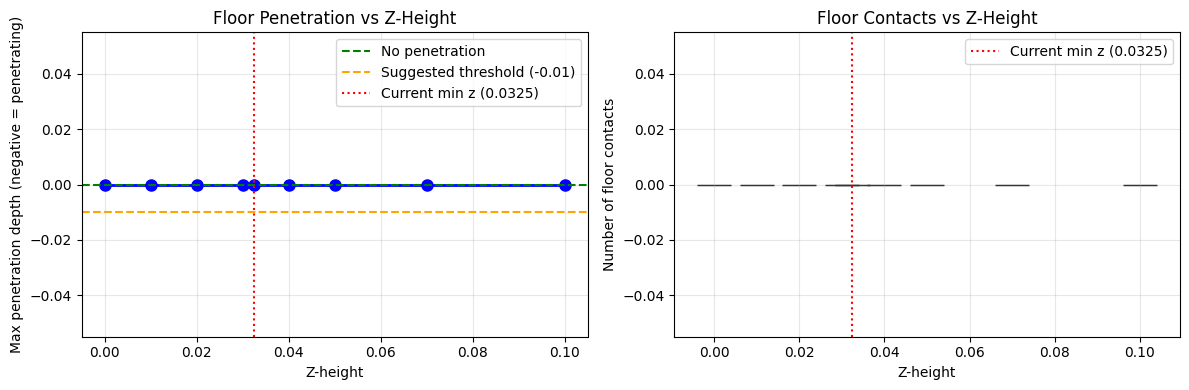


SUGGESTED PENETRATION THRESHOLD

Based on the contact data above, you can choose a penetration threshold.

Typical values:
- dist = 0: Geoms just touching (no penetration)
- dist < 0: Penetration (more negative = deeper)
- dist > 0: Gap between geoms

A reasonable threshold might be around -0.005 to -0.01 for detecting
when the rodent has "fallen" and is clipping through the floor.



In [20]:
# Plot penetration depth vs z-height
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

z_vals = [r["z_height"] for r in results]
penetrations = [r["max_penetration"] for r in results]
num_floor_contacts = [r["num_floor_contacts"] for r in results]

# Plot 1: Penetration depth vs z-height
ax1 = axes[0]
ax1.plot(z_vals, penetrations, 'bo-', linewidth=2, markersize=8)
ax1.axhline(y=0, color='green', linestyle='--', label='No penetration')
ax1.axhline(y=-0.01, color='orange', linestyle='--', label='Suggested threshold (-0.01)')
ax1.axvline(x=HEALTHY_Z_RANGE[0], color='red', linestyle=':', label=f'Current min z ({HEALTHY_Z_RANGE[0]})')
ax1.set_xlabel("Z-height")
ax1.set_ylabel("Max penetration depth (negative = penetrating)")
ax1.set_title("Floor Penetration vs Z-Height")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Number of floor contacts vs z-height
ax2 = axes[1]
ax2.bar(z_vals, num_floor_contacts, width=0.008, color='steelblue', edgecolor='black')
ax2.axvline(x=HEALTHY_Z_RANGE[0], color='red', linestyle=':', label=f'Current min z ({HEALTHY_Z_RANGE[0]})')
ax2.set_xlabel("Z-height")
ax2.set_ylabel("Number of floor contacts")
ax2.set_title("Floor Contacts vs Z-Height")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print("\n" + "=" * 60)
print("SUGGESTED PENETRATION THRESHOLD")
print("=" * 60)
print("""
Based on the contact data above, you can choose a penetration threshold.

Typical values:
- dist = 0: Geoms just touching (no penetration)
- dist < 0: Penetration (more negative = deeper)
- dist > 0: Gap between geoms

A reasonable threshold might be around -0.005 to -0.01 for detecting
when the rodent has "fallen" and is clipping through the floor.
""")

## 2.7 Penetration-Based Termination Check

Define a termination function that uses contact penetration depth instead of (or in addition to) z-height threshold.

In [21]:
def check_termination_with_penetration(
    mj_model,
    mj_data,
    healthy_z_range: Tuple[float, float] = (0.0325, 0.5),
    max_penetration: float = -0.01,
    use_z_check: bool = True,
    use_penetration_check: bool = True,
) -> Tuple[bool, Dict[str, Any]]:
    """
    Check termination using contact penetration depth.
    
    This is a MuJoCo (not MJX) version for use in the notebook.
    
    Args:
        mj_model: MuJoCo model
        mj_data: MuJoCo data (after mj_forward)
        healthy_z_range: (min_z, max_z) for z-height check
        max_penetration: Maximum allowed penetration (negative value).
            Terminates if any contact.dist < max_penetration.
        use_z_check: Whether to use z-height termination
        use_penetration_check: Whether to use penetration termination
        
    Returns:
        Tuple of (is_terminated, details_dict)
    """
    details = {
        "torso_z": mj_data.qpos[2],
        "healthy_z_range": healthy_z_range,
        "max_penetration_threshold": max_penetration,
    }
    
    terminated = False
    termination_reasons = []
    
    # Check NaN
    has_nan = np.any(np.isnan(mj_data.qpos)) or np.any(np.isnan(mj_data.qvel))
    details["has_nan"] = has_nan
    if has_nan:
        terminated = True
        termination_reasons.append("NaN detected")
    
    # Check z-height
    if use_z_check:
        torso_z = mj_data.qpos[2]
        min_z, max_z = healthy_z_range
        z_too_low = torso_z < min_z
        z_too_high = torso_z > max_z
        details["z_too_low"] = z_too_low
        details["z_too_high"] = z_too_high
        if z_too_low:
            terminated = True
            termination_reasons.append(f"z too low ({torso_z:.4f} < {min_z})")
        if z_too_high:
            terminated = True
            termination_reasons.append(f"z too high ({torso_z:.4f} > {max_z})")
    
    # Check penetration
    if use_penetration_check:
        max_pen_found = 0.0
        penetrating_geoms = []
        
        for i in range(mj_data.ncon):
            contact = mj_data.contact[i]
            if contact.dist < max_pen_found:
                max_pen_found = contact.dist
            
            if contact.dist < max_penetration:
                geom1_name = mj_model.geom(contact.geom1).name
                geom2_name = mj_model.geom(contact.geom2).name
                penetrating_geoms.append({
                    "geom1": geom1_name,
                    "geom2": geom2_name,
                    "dist": contact.dist,
                })
        
        details["max_penetration_found"] = max_pen_found
        details["penetrating_geoms"] = penetrating_geoms
        details["has_deep_penetration"] = len(penetrating_geoms) > 0
        
        if len(penetrating_geoms) > 0:
            terminated = True
            termination_reasons.append(f"deep penetration ({max_pen_found:.4f} < {max_penetration})")
    
    details["terminated"] = terminated
    details["termination_reasons"] = termination_reasons
    
    return terminated, details


# ============================================================
# TEST THE PENETRATION-BASED TERMINATION
# ============================================================

# Configuration
MAX_PENETRATION_THRESHOLD = -0.01  # Terminate if penetration exceeds 1cm

print("Testing penetration-based termination at different z-heights:")
print(f"Max penetration threshold: {MAX_PENETRATION_THRESHOLD}")
print(f"Z-height range: {HEALTHY_Z_RANGE}")
print("=" * 70)

test_z_values = [0.0, 0.01, 0.02, 0.03, 0.0325, 0.04, 0.05]

for z in test_z_values:
    # Set up pose
    neutral_qpos = env.mj_model.qpos0.copy()
    neutral_qpos[2] = z
    
    mj_data_test = mujoco.MjData(env.mj_model)
    mj_data_test.qpos[:] = neutral_qpos
    mj_data_test.qvel[:] = 0.0
    mujoco.mj_forward(env.mj_model, mj_data_test)
    
    # Check termination with different criteria
    term_z_only, _ = check_termination_with_penetration(
        env.mj_model, mj_data_test, HEALTHY_Z_RANGE, MAX_PENETRATION_THRESHOLD,
        use_z_check=True, use_penetration_check=False
    )
    term_pen_only, details = check_termination_with_penetration(
        env.mj_model, mj_data_test, HEALTHY_Z_RANGE, MAX_PENETRATION_THRESHOLD,
        use_z_check=False, use_penetration_check=True
    )
    term_both, _ = check_termination_with_penetration(
        env.mj_model, mj_data_test, HEALTHY_Z_RANGE, MAX_PENETRATION_THRESHOLD,
        use_z_check=True, use_penetration_check=True
    )
    
    z_status = "TERM" if term_z_only else "OK"
    pen_status = "TERM" if term_pen_only else "OK"
    both_status = "TERM" if term_both else "OK"
    
    print(f"z={z:.4f}: z-check={z_status:4s}, pen-check={pen_status:4s}, both={both_status:4s} | max_pen={details['max_penetration_found']:.4f}")

Testing penetration-based termination at different z-heights:
Max penetration threshold: -0.01
Z-height range: (0.0325, 0.5)
z=0.0000: z-check=TERM, pen-check=OK  , both=TERM | max_pen=0.0000
z=0.0100: z-check=TERM, pen-check=OK  , both=TERM | max_pen=0.0000
z=0.0200: z-check=TERM, pen-check=OK  , both=TERM | max_pen=0.0000
z=0.0300: z-check=TERM, pen-check=OK  , both=TERM | max_pen=0.0000
z=0.0325: z-check=OK  , pen-check=OK  , both=OK   | max_pen=0.0000
z=0.0400: z-check=OK  , pen-check=OK  , both=OK   | max_pen=0.0000
z=0.0500: z-check=OK  , pen-check=OK  , both=OK   | max_pen=0.0000


## 3. Create Teacher Policy

In [7]:
# Create the inference function from checkpoint
inference_fn = checkpointing.load_inference_fn(
    cfg, 
    policy_params, 
    deterministic=DETERMINISTIC, 
    get_activation=False
)

# JIT compile environment functions
jit_step = jax.jit(env.step)
jit_reset = jax.jit(env.reset)

print(f"Teacher policy created!")
print(f"Deterministic: {DETERMINISTIC}")

Teacher policy created!
Deterministic: True


## 4. Termination Checking Functions

These are the same criteria used in `PriorRolloutEvaluator`.

In [8]:
def check_termination(
    data: Any,
    healthy_z_range: Tuple[float, float] = (0.0325, 0.5),
) -> Tuple[bool, Dict[str, Any]]:
    """
    Check if a state should be terminated based on PriorRolloutEvaluator criteria.
    
    Criteria:
    1. NaN detection in qpos/qvel
    2. Torso z-height outside healthy range
    
    Returns:
        Tuple of (is_terminated, details_dict)
    """
    from jax import flatten_util
    
    # Check for NaN values
    flattened_qpos, _ = flatten_util.ravel_pytree(data.qpos)
    flattened_qvel, _ = flatten_util.ravel_pytree(data.qvel)
    all_vals = jnp.concatenate([flattened_qpos, flattened_qvel])
    has_nan = bool(jnp.any(jnp.isnan(all_vals)))
    
    # Check torso height
    torso_z = float(data.qpos[2])
    min_z, max_z = healthy_z_range
    z_too_low = torso_z < min_z
    z_too_high = torso_z > max_z
    z_out_of_range = z_too_low or z_too_high
    
    is_terminated = has_nan or z_out_of_range
    
    details = {
        "terminated": is_terminated,
        "has_nan": has_nan,
        "torso_z": torso_z,
        "z_too_low": z_too_low,
        "z_too_high": z_too_high,
        "z_out_of_range": z_out_of_range,
        "healthy_z_range": healthy_z_range,
    }
    
    return is_terminated, details


def check_termination_jax(
    data: Any,
    healthy_z_range: Tuple[float, float] = (0.0325, 0.5),
) -> jax.Array:
    """
    JAX-compatible termination check (same as prior_rollout.check_termination).
    """
    return prior_rollout.check_termination(data, healthy_z_range)


print("Termination functions defined!")
print(f"Healthy z range: {HEALTHY_Z_RANGE}")

Termination functions defined!
Healthy z range: (0.0325, 0.5)


## 5. Run Teacher Rollouts with Termination Tracking

In [9]:
def run_teacher_rollout(
    env,
    inference_fn: Callable,
    jit_step: Callable,
    jit_reset: Callable,
    rng_key: jax.Array,
    num_steps: int,
    healthy_z_range: Tuple[float, float] = (0.0325, 0.5),
    clip_idx: int = 0,
    start_frame: int = 0,
    verbose: bool = True,
) -> Dict:
    """
    Run a teacher rollout on an imitation sequence with termination checking.
    
    Args:
        env: The imitation environment
        inference_fn: Teacher inference function
        jit_step: JIT-compiled step function
        jit_reset: JIT-compiled reset function  
        rng_key: Random key
        num_steps: Number of steps to run
        healthy_z_range: (min_z, max_z) for termination checking
        clip_idx: Which clip to imitate
        start_frame: Starting frame in the clip
        verbose: Whether to print termination info
        
    Returns:
        Dictionary with rollout data and termination info
    """
    from jax import flatten_util
    
    # Reset environment to specific clip
    state = jit_reset(rng_key, clip_idx=clip_idx, start_frame=start_frame)
    
    # Storage
    rollout_states = [state]
    actions = []
    z_heights = [float(state.data.qpos[2])]
    termination_details_history = []
    
    termination_step = None
    termination_reason = None
    
    for step_idx in range(num_steps):
        rng_key, action_key = random.split(rng_key)
        
        # Get flattened observation
        if hasattr(state.obs, 'get') or isinstance(state.obs, dict):
            obs_flat, _ = flatten_util.ravel_pytree(state.obs)
        else:
            obs_flat = state.obs
        
        # Get action from teacher
        action, extras = inference_fn(obs_flat, action_key)
        actions.append(action)
        
        # Step environment
        state = jit_step(state, action)
        rollout_states.append(state)
        z_heights.append(float(state.data.qpos[2]))
        
        # Check termination
        is_terminated, details = check_termination(state.data, healthy_z_range)
        termination_details_history.append(details)
        
        if is_terminated and termination_step is None:
            termination_step = step_idx + 1
            if details["has_nan"]:
                termination_reason = "NaN detected"
            elif details["z_too_low"]:
                termination_reason = f"z too low ({details['torso_z']:.4f} < {healthy_z_range[0]})"
            elif details["z_too_high"]:
                termination_reason = f"z too high ({details['torso_z']:.4f} > {healthy_z_range[1]})"
            
            if verbose:
                print(f"  TERMINATED at step {termination_step}: {termination_reason}")
    
    return {
        "rollout_states": rollout_states,
        "actions": actions,
        "z_heights": z_heights,
        "termination_details_history": termination_details_history,
        "terminated": termination_step is not None,
        "termination_step": termination_step,
        "termination_reason": termination_reason,
        "clip_idx": clip_idx,
        "start_frame": start_frame,
        "final_z": z_heights[-1],
        "num_steps": num_steps,
    }


print("Rollout function defined!")

Rollout function defined!


In [10]:
# Run rollouts on different clips
rollouts = []
base_key = random.PRNGKey(42)

print(f"Running {NUM_ROLLOUTS} teacher rollouts on imitation sequences...")
print(f"Deterministic: {DETERMINISTIC}")
print(f"Num steps: {NUM_STEPS}")
print(f"Healthy z range: {HEALTHY_Z_RANGE}")
print("-" * 60)

for i in range(NUM_ROLLOUTS):
    print(f"\nRollout {i + 1} (clip_idx={i}):")
    key = random.fold_in(base_key, i)
    
    rollout = run_teacher_rollout(
        env=env,
        inference_fn=inference_fn,
        jit_step=jit_step,
        jit_reset=jit_reset,
        rng_key=key,
        num_steps=NUM_STEPS,
        healthy_z_range=HEALTHY_Z_RANGE,
        clip_idx=i,
        start_frame=0,
        verbose=True,
    )
    rollouts.append(rollout)
    
    if not rollout["terminated"]:
        print(f"  Completed {NUM_STEPS} steps without termination")
    print(f"  Final z: {rollout['final_z']:.4f}")
    print(f"  Z range during rollout: [{min(rollout['z_heights']):.4f}, {max(rollout['z_heights']):.4f}]")

Running 5 teacher rollouts on imitation sequences...
Deterministic: True
Num steps: 500
Healthy z range: (0.0325, 0.5)
------------------------------------------------------------

Rollout 1 (clip_idx=0):
  TERMINATED at step 1: z too low (0.0226 < 0.0325)
  Final z: 0.0077
  Z range during rollout: [-0.0051, 0.0279]

Rollout 2 (clip_idx=1):
  TERMINATED at step 1: z too low (0.0086 < 0.0325)
  Final z: 0.1152
  Z range during rollout: [-0.0017, 0.1371]

Rollout 3 (clip_idx=2):
  TERMINATED at step 1: z too low (0.0151 < 0.0325)
  Final z: -0.0125
  Z range during rollout: [-0.0153, 0.0160]

Rollout 4 (clip_idx=3):
  TERMINATED at step 158: z too low (0.0318 < 0.0325)
  Final z: 0.0063
  Z range during rollout: [-0.0032, 0.1343]

Rollout 5 (clip_idx=4):
  TERMINATED at step 1: z too low (0.0114 < 0.0325)
  Final z: 0.0138
  Z range during rollout: [0.0014, 0.0334]


## 6. Summary Statistics

In [ ]:
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

num_terminated = sum(1 for r in rollouts if r["terminated"])
termination_rate = num_terminated / len(rollouts) * 100

print(f"\nTotal rollouts: {len(rollouts)}")
print(f"Terminated: {num_terminated} ({termination_rate:.1f}%)")
print(f"Completed full episode: {len(rollouts) - num_terminated} ({100 - termination_rate:.1f}%)")

if num_terminated > 0:
    terminated_steps = [r["termination_step"] for r in rollouts if r["terminated"]]
    print(f"\nTermination steps: min={min(terminated_steps)}, max={max(terminated_steps)}, mean={np.mean(terminated_steps):.1f}")
    
    print("\nTermination reasons:")
    for r in rollouts:
        if r["terminated"]:
            print(f"  Clip {r['clip_idx']}: step {r['termination_step']} - {r['termination_reason']}")

# Z-height statistics
all_z_heights = [z for r in rollouts for z in r["z_heights"]]
print(f"\nZ-height statistics across all rollouts:")
print(f"  Min: {min(all_z_heights):.4f}")
print(f"  Max: {max(all_z_heights):.4f}")
print(f"  Mean: {np.mean(all_z_heights):.4f}")
print(f"  Std: {np.std(all_z_heights):.4f}")

## 8. Render Rollout Video

In [11]:
import mujoco

def render_rollout(env, rollout_states, height=480, width=640, camera="side-rodent"):
    """Render a rollout to video frames."""
    renderer = mujoco.Renderer(env.mj_model, height=height, width=width)
    mj_data = mujoco.MjData(env.mj_model)
    
    frames = []
    for state in rollout_states:
        mj_data.qpos[:] = np.array(state.data.qpos)
        mj_data.qvel[:] = np.array(state.data.qvel)
        mujoco.mj_forward(env.mj_model, mj_data)
        renderer.update_scene(mj_data, camera=camera)
        frames.append(renderer.render())
    return frames

# Render first rollout (or first terminated rollout if any)
rollout_to_render = rollouts[0]
for r in rollouts:
    if r["terminated"]:
        rollout_to_render = r
        break

print(f"Rendering rollout for clip {rollout_to_render['clip_idx']}...")
if rollout_to_render["terminated"]:
    print(f"  (Terminated at step {rollout_to_render['termination_step']}: {rollout_to_render['termination_reason']})")

video_frames = render_rollout(env, rollout_to_render["rollout_states"])
print(f"Rendered {len(video_frames)} frames")

media.show_video(video_frames, fps=50)

Rendering rollout for clip 0...
  (Terminated at step 1: z too low (0.0226 < 0.0325))
Rendered 501 frames


This browser does not support the video tag.


## 9. Detailed Termination Analysis

In [ ]:
# Analyze termination patterns
print("Detailed Termination Analysis")
print("=" * 60)

for rollout in rollouts:
    print(f"\nClip {rollout['clip_idx']}:")
    
    # Find steps where z was close to boundaries
    z_heights = rollout["z_heights"]
    min_z, max_z = HEALTHY_Z_RANGE
    
    # Steps near lower boundary
    near_lower = [(i, z) for i, z in enumerate(z_heights) if z < min_z + 0.02]
    near_upper = [(i, z) for i, z in enumerate(z_heights) if z > max_z - 0.02]
    
    print(f"  Min z reached: {min(z_heights):.4f} at step {z_heights.index(min(z_heights))}")
    print(f"  Max z reached: {max(z_heights):.4f} at step {z_heights.index(max(z_heights))}")
    
    if near_lower:
        print(f"  Steps near lower boundary (<{min_z + 0.02:.4f}): {len(near_lower)}")
    if near_upper:
        print(f"  Steps near upper boundary (>{max_z - 0.02:.4f}): {len(near_upper)}")
    
    if rollout["terminated"]:
        step = rollout["termination_step"]
        details = rollout["termination_details_history"][step - 1]
        print(f"  TERMINATED: {rollout['termination_reason']}")
        print(f"    At step {step}, z = {details['torso_z']:.4f}")
    else:
        print(f"  Completed all {NUM_STEPS} steps")

## 10. Compare with Reference Trajectory (Optional)

If you want to see how the teacher's z-height compares to the reference motion data.

In [ ]:
# This cell shows how to extract reference z-heights if available in the environment
# The exact implementation depends on your environment's data structure

try:
    # Example: extract reference trajectory data (implementation depends on env)
    # Uncomment and modify based on your environment's API
    
    # for rollout in rollouts[:1]:  # Just first rollout
    #     clip_idx = rollout["clip_idx"]
    #     # Access reference data from environment
    #     ref_qpos = env._reference_clip_data[clip_idx].qpos  # Example path
    #     ref_z = ref_qpos[:, 2]  # z is typically index 2
    #     
    #     plt.figure(figsize=(12, 4))
    #     plt.plot(rollout["z_heights"], label="Teacher", alpha=0.8)
    #     plt.plot(ref_z[:len(rollout["z_heights"])], label="Reference", alpha=0.8)
    #     plt.axhline(y=HEALTHY_Z_RANGE[0], color='red', linestyle='--', label='Min z')
    #     plt.axhline(y=HEALTHY_Z_RANGE[1], color='red', linestyle='--', label='Max z')
    #     plt.xlabel("Step")
    #     plt.ylabel("Z Height")
    #     plt.title(f"Teacher vs Reference Z-Height (Clip {clip_idx})")
    #     plt.legend()
    #     plt.show()
    
    print("Reference comparison not implemented - modify based on your environment's API")
    
except Exception as e:
    print(f"Could not extract reference data: {e}")

## Conclusion

This notebook demonstrates:
1. Loading a trained teacher checkpoint and creating the inference function
2. Rolling out the teacher on imitation sequences
3. Applying the same termination criteria as `PriorRolloutEvaluator`:
   - NaN detection in physics state
   - Torso z-height outside healthy range (0.0325, 0.5)
4. Visualizing z-height trajectories and termination patterns

**Key insights for validating termination criteria:**
- If the teacher frequently triggers termination, the criteria may be too strict
- If terminations happen early in rollouts, check if the z-range is appropriate for your motion data
- Compare teacher z-heights with reference trajectory to see if the criteria match expected behavior